<a href="https://colab.research.google.com/github/Subhankar9-star/PRODIGY_DS_03/blob/main/PRODIGY_DS_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Accuracy: 0.8959

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.65      0.30      0.41      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



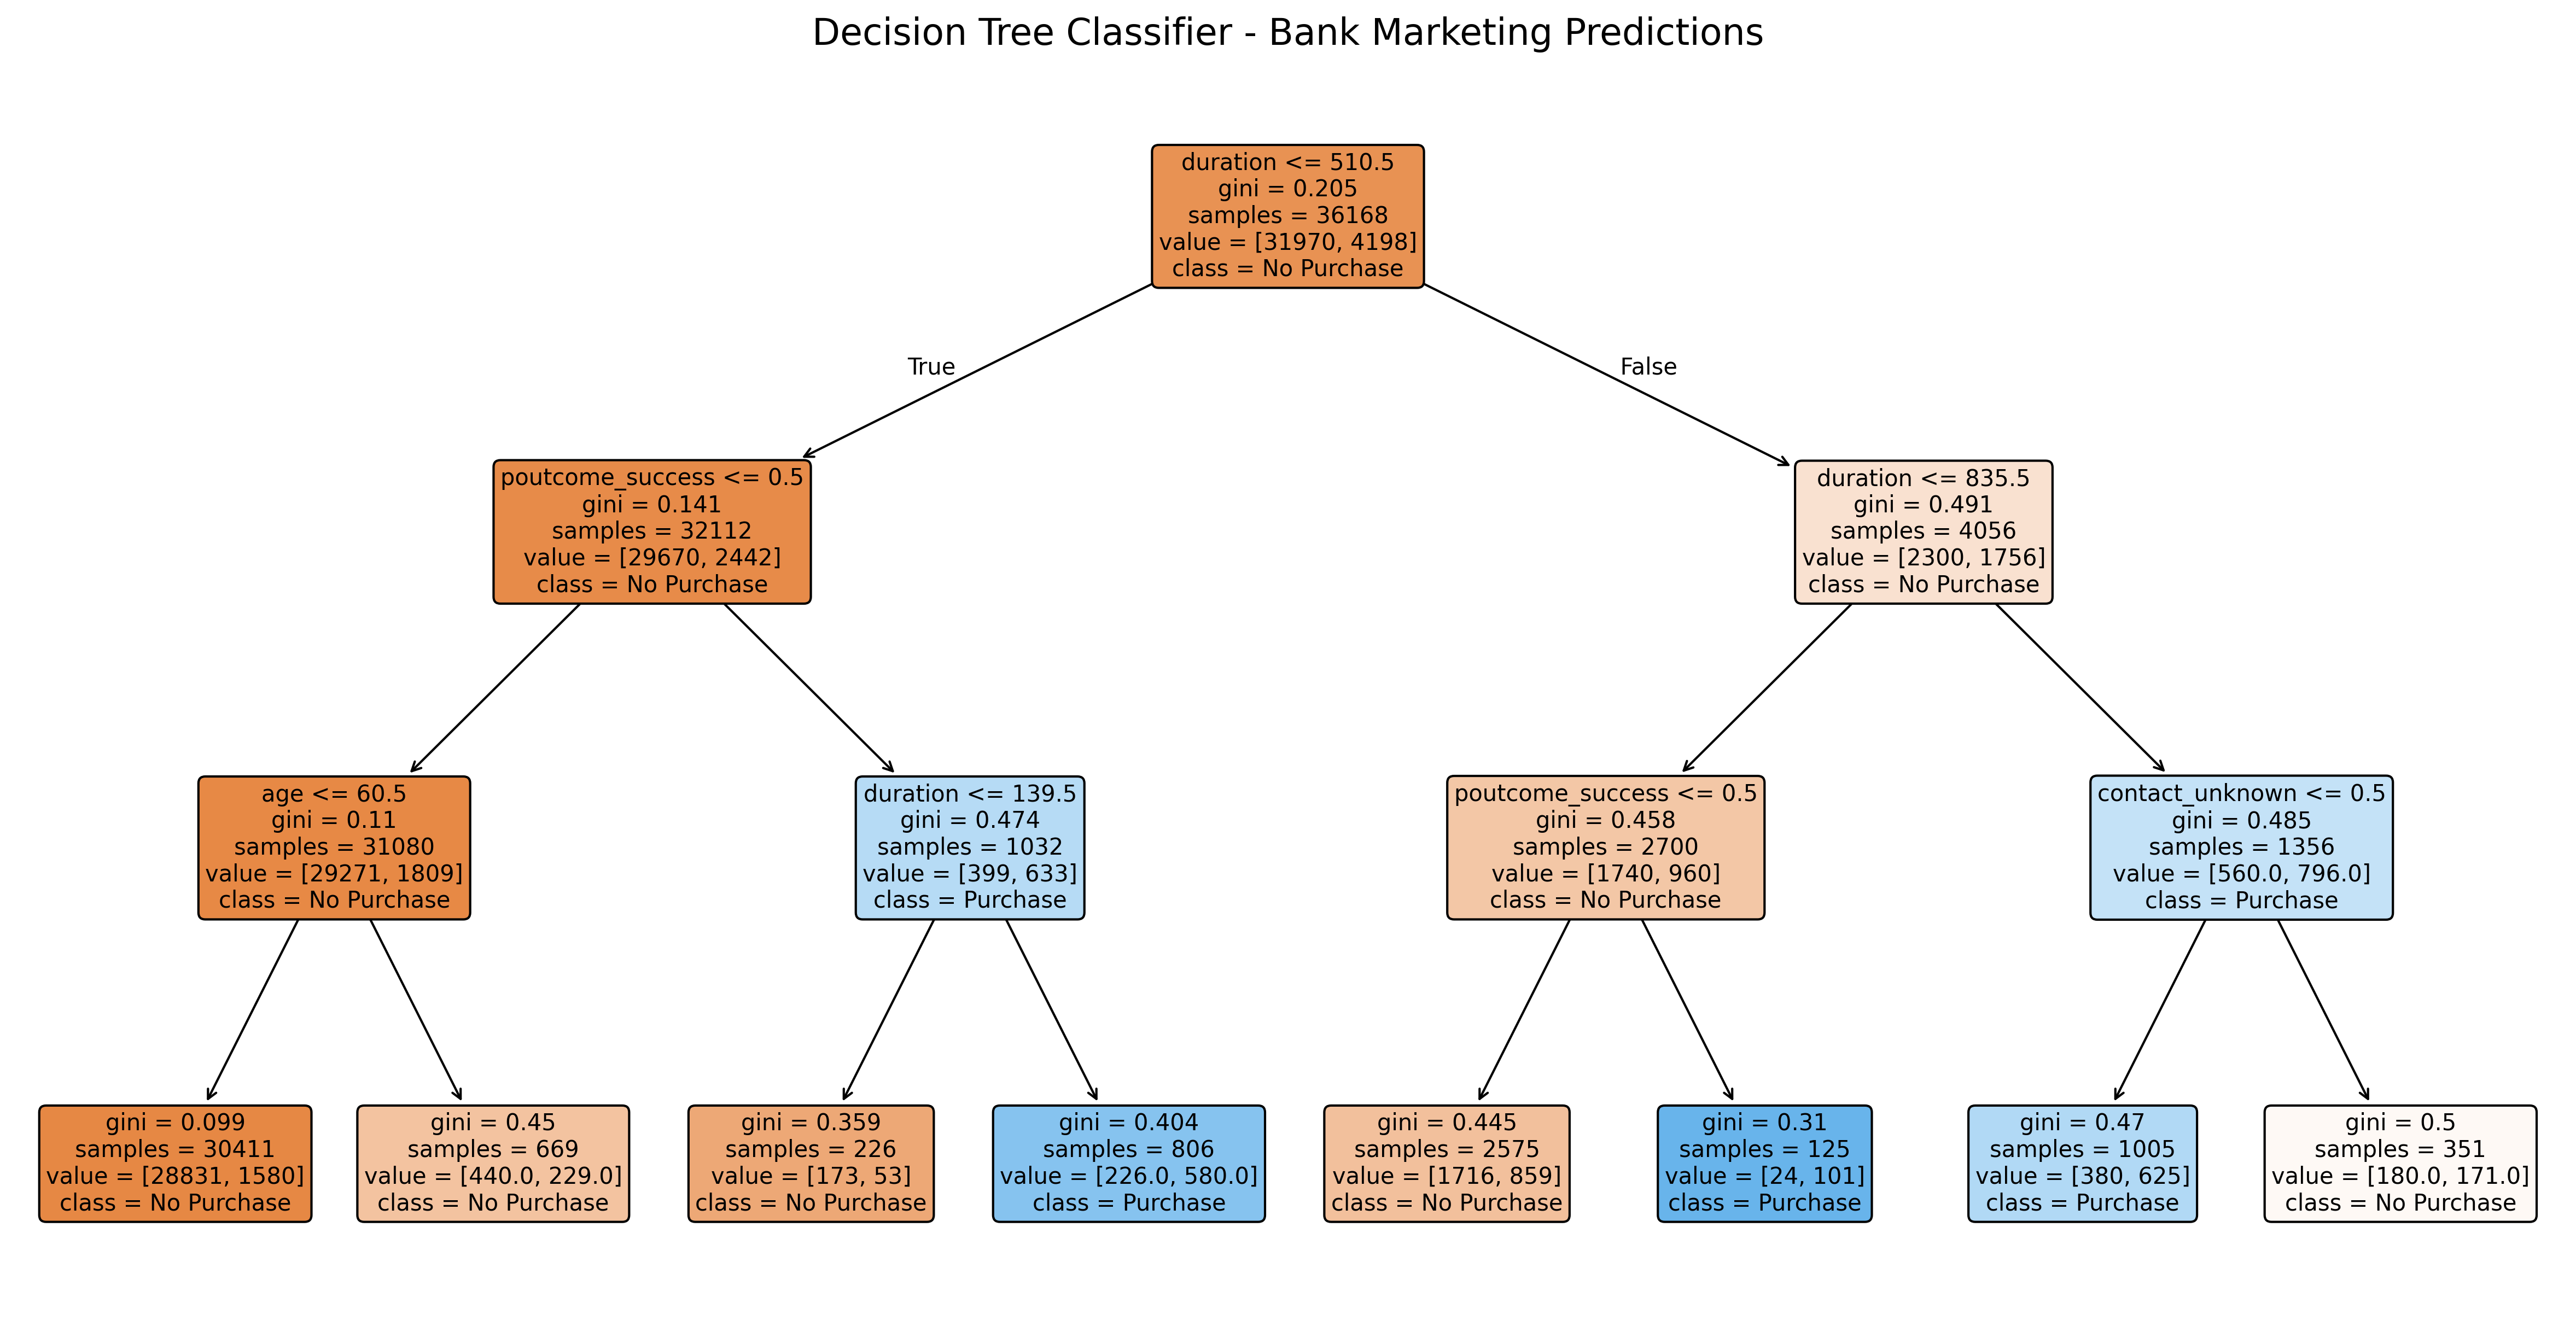

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://raw.githubusercontent.com/skathirmani/datasets/master/bank-full.csv"
df = pd.read_csv(url, sep=';')

X = df.drop(columns=['y'])
X = pd.get_dummies(X, drop_first=True)
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=['No Purchase', 'Purchase'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Classifier - Bank Marketing Predictions", fontsize=16)
plt.show()